
Regresión Logística

---

In [196]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [197]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/TC4029 - Ciencia y analítica de datos/Semana 9/Actividad9_RLog"
os.chdir(DIR)

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento e ing de características
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.compose import make_column_transformer

# Librerías para la canalización
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

In [199]:
data_df = pd.read_csv('data.csv')
data_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# **Parte 1**. EDA

Haz que el `id` sea el índice del dataframe y efectúa una exploración inicial de los datos a través de:

In [200]:
data_df.set_index('id', inplace=True)



1a) Estadísticas descriptivas para todas las variables del dataframe.

In [201]:
#Se despliega la información general del dataframe
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

In [202]:
#Se obtienen las estadisticas descriptivas de las variables numéricas
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [203]:
#Se despliega las estadisticas descriptivas de las variables de texto
data_df.describe(include='object').T

,count,unique,top,freq
diagnosis,569,2,B,357


1b) Valores únicos por variable para identificar posibles variables categóricas.

In [204]:
#Se despliegan los valores únicos por variable
data_df.nunique()

,0
diagnosis,2
radius_mean,456
texture_mean,479
perimeter_mean,522
area_mean,539
smoothness_mean,474
compactness_mean,537
concavity_mean,537
concave points_mean,542
symmetry_mean,432




---
***Se observa que la variable diagnosis es de tipo categórica ya que cuenta solo con 2 valores únicos y es de tipo objeto***


---




1c) Búsqueda de valores faltantes.

In [205]:
#Se calcula cuantos valores faltantes hay en el conjunto de datos
data_df.isna().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0



---

***Se observa que no hay ningun valor faltante***


---

1d) Diagrama de barras para determinar la frecuencia de los diagnósticos (cantidad de observaciones con resultado benigno y maligno)

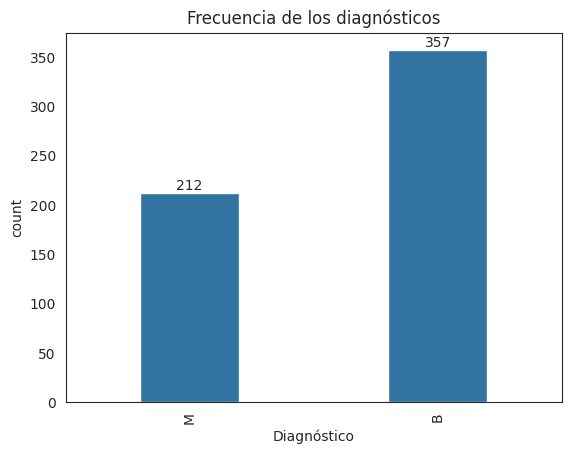

In [206]:
#Se obtiene el gráfico de barras para la variable diagnosis
ax = sns.countplot(x=data_df['diagnosis'],width = 0.4)
plt.title("Frecuencia de los diagnósticos")
plt.xlabel("Diagnóstico")
plt.xticks(rotation=90)
plt.bar_label(ax.containers[0])
plt.show()

2. Como hay tres valores relacionados con la misma característica (`mean`, `se` y `worst`) es muy probable que exista multicolinealidad en el conjunto.

La multicolinealidad en regresión es una condición que ocurre cuando algunas variables predictoras están fuertemente correlacionadas entre sí, de tal manera que si se incluyen simultáneamente en un modelo, impiden explicar de manera correcta el efecto que cada una tiene sobre la variable respuesta. Existen muchas formas de analizar si hay colinealidad en los modelos, una de ellas es el alto coeficiente de correlación entre variables.

Para observar este efecto, elabora un mapa de calor que cuantifique la correlación de las variables numéricas en el dataframe.

<Axes: >

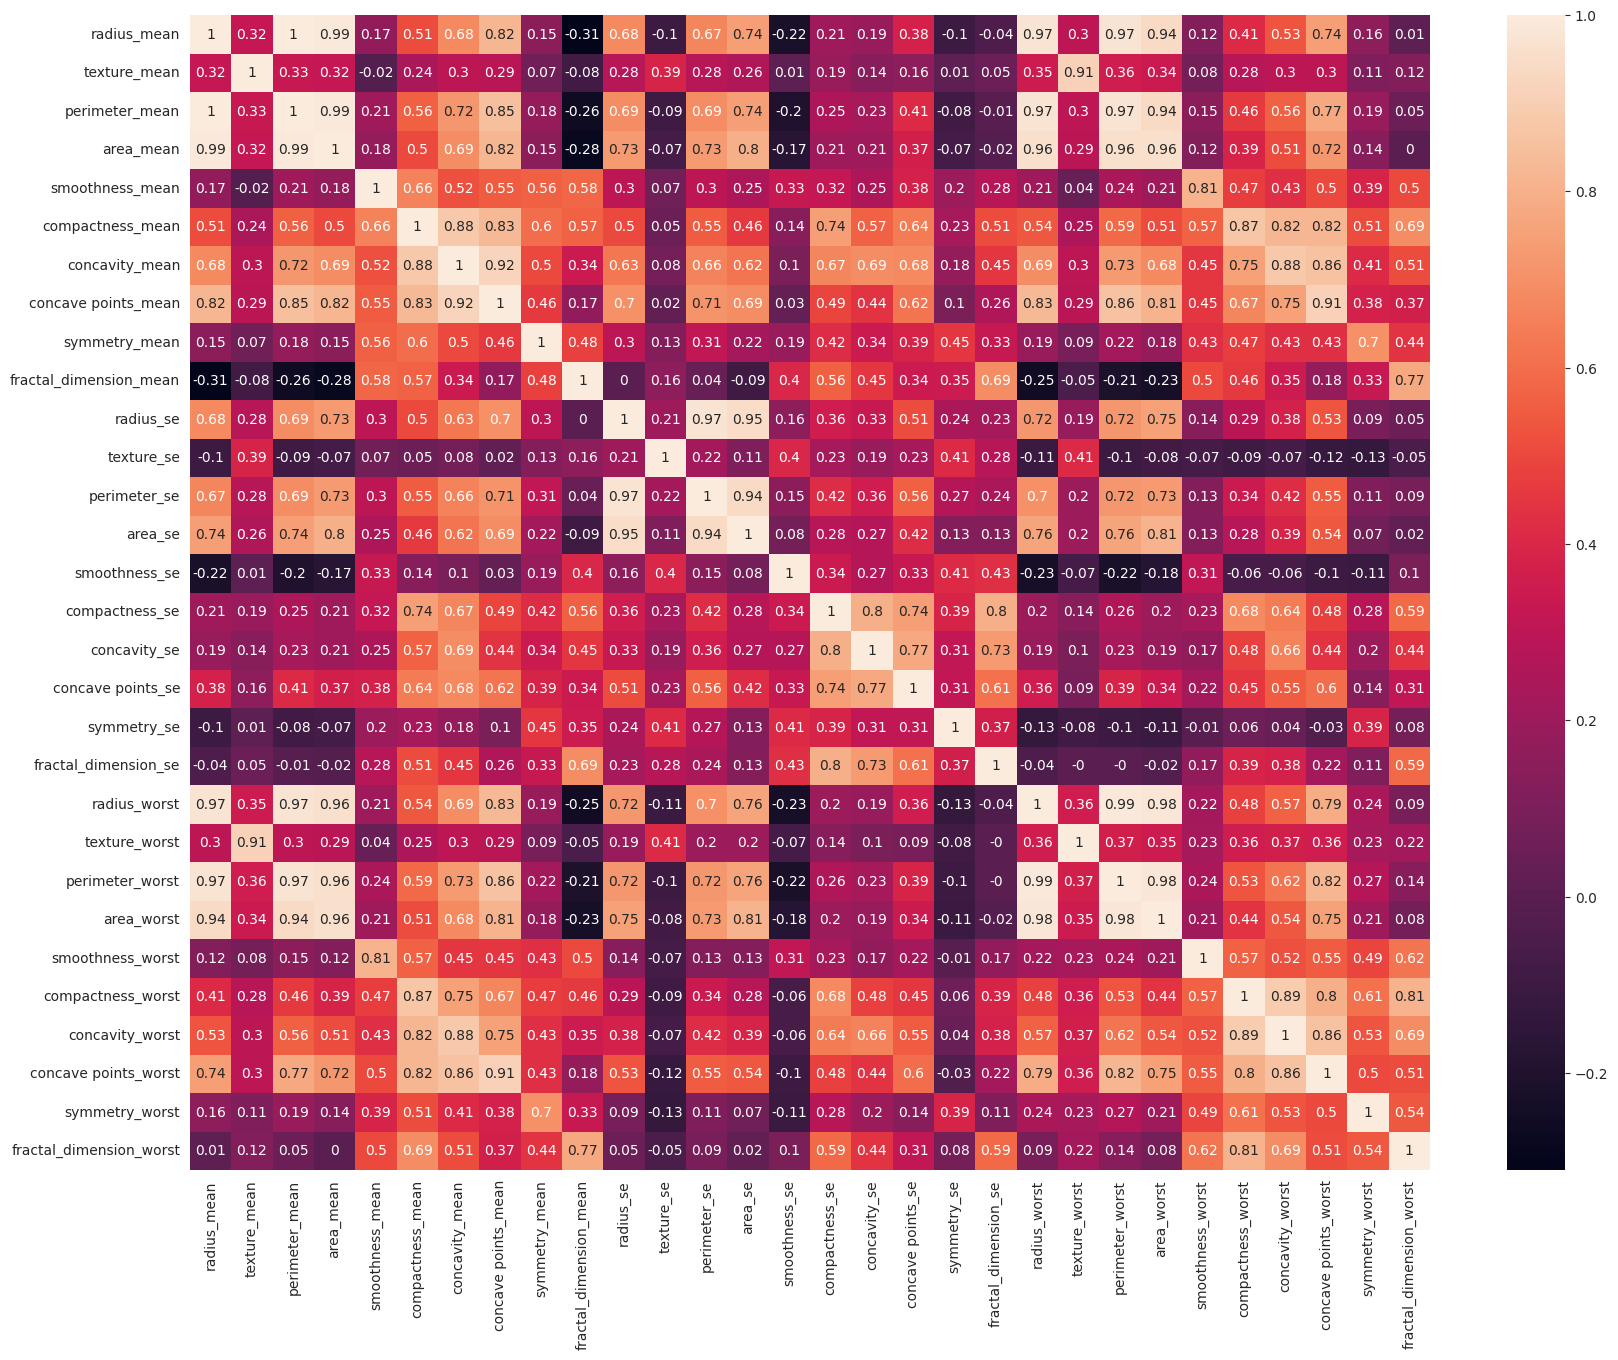

In [207]:
#Se despliega el mapa de calor para todas las variables numéricas
plt.figure(figsize = (20, 15))
sns.heatmap(round(data_df.corr (numeric_only = True),2), annot = True)

Si te fijas en los valores de correlación entre las variables `_mean` y `_worst` es evidente la multicolinearidad.

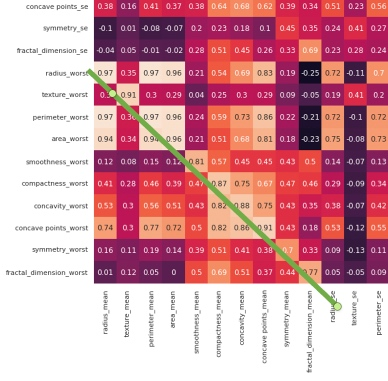

Por ejemplo, la columna `radius_mean` tiene una correlación de 0.97 con la columna `radius_worst`. Esto es algo inevitable, porque las columnas "peores" son esencialmente solo un subconjunto de las columnas "medias".

Para solucionar el problema numérico de la multicolinealidad, tradicionalmente se recurre a eliminar variables o efectuar análisis de componentes principales (PCA) con las `X`’s y usar los componentes como variables independientes en un modelo final.

Conduciremos esta actividad en esos dos sentidos.


# **Parte 2**. Modelo con eliminación de variables altamente correlacionadas  

Elimina las variables altamente correlacionadas:

3a) Ahora que sabes que las variables `_mean` y `_worst` tienen correlación alta, hay que quitar del dataframe un conjunto. Borra las columnas `_worst`.

In [208]:
#Se borran las columnas worst del dataframe
data_df = data_df.drop(columns=['radius_worst','texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'])
data_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892


3b. Entre las variables `_mean`, identifica patrones lineales con diagramas de dispersión usando:



```Python
sns.pairplot(data=data_df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean']])
```




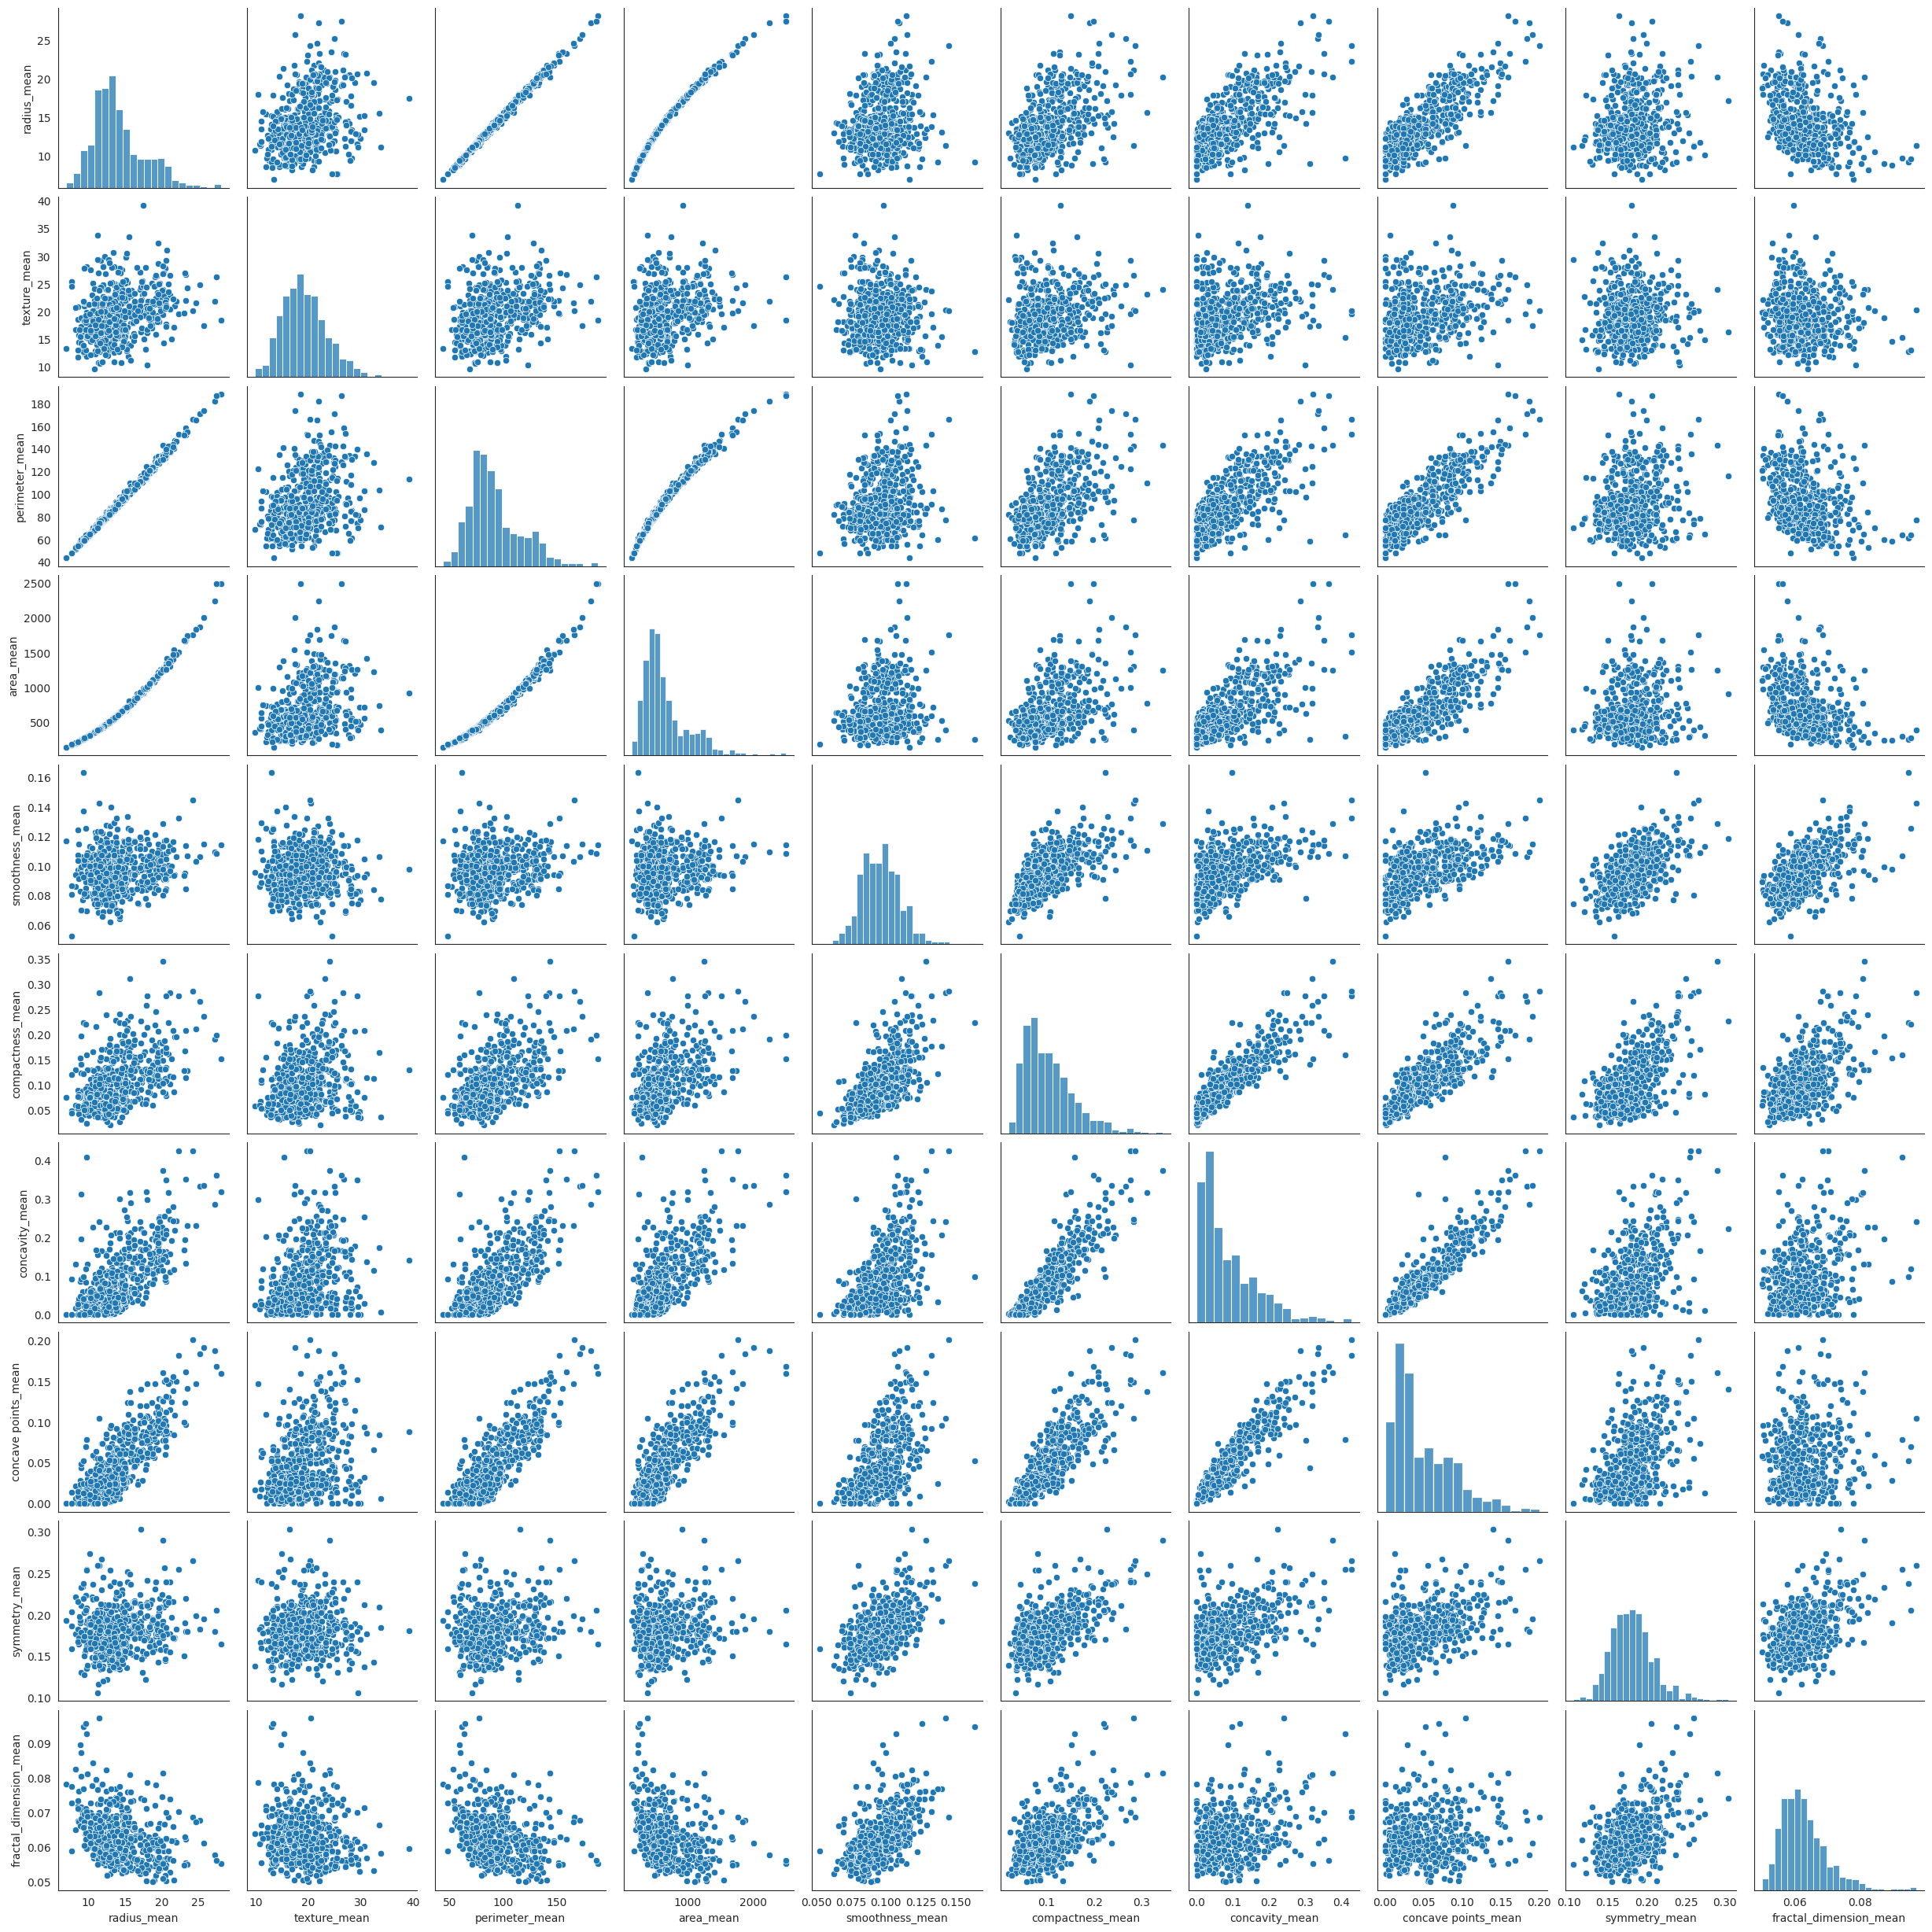

In [209]:
#Diagramas de dispersión de las variables
sns.pairplot(data=data_df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean']])

De la matriz podrás observar relaciones lineales bastante evidentes entre:


*   `radius_mean`, `perimeter_mean` y `area_mean`
*   `compactness_mean`, `concavity_mean`, `concave_points_mean`

Sabemos que el perímetro y el área de un círculo, se calculan a partir del radio. Entonces, la relación entre las primeras tres variables es muy clara para nosotros.

3c) Elabora otro mapa de calor confirmar con los valores de correlación.


<Axes: >

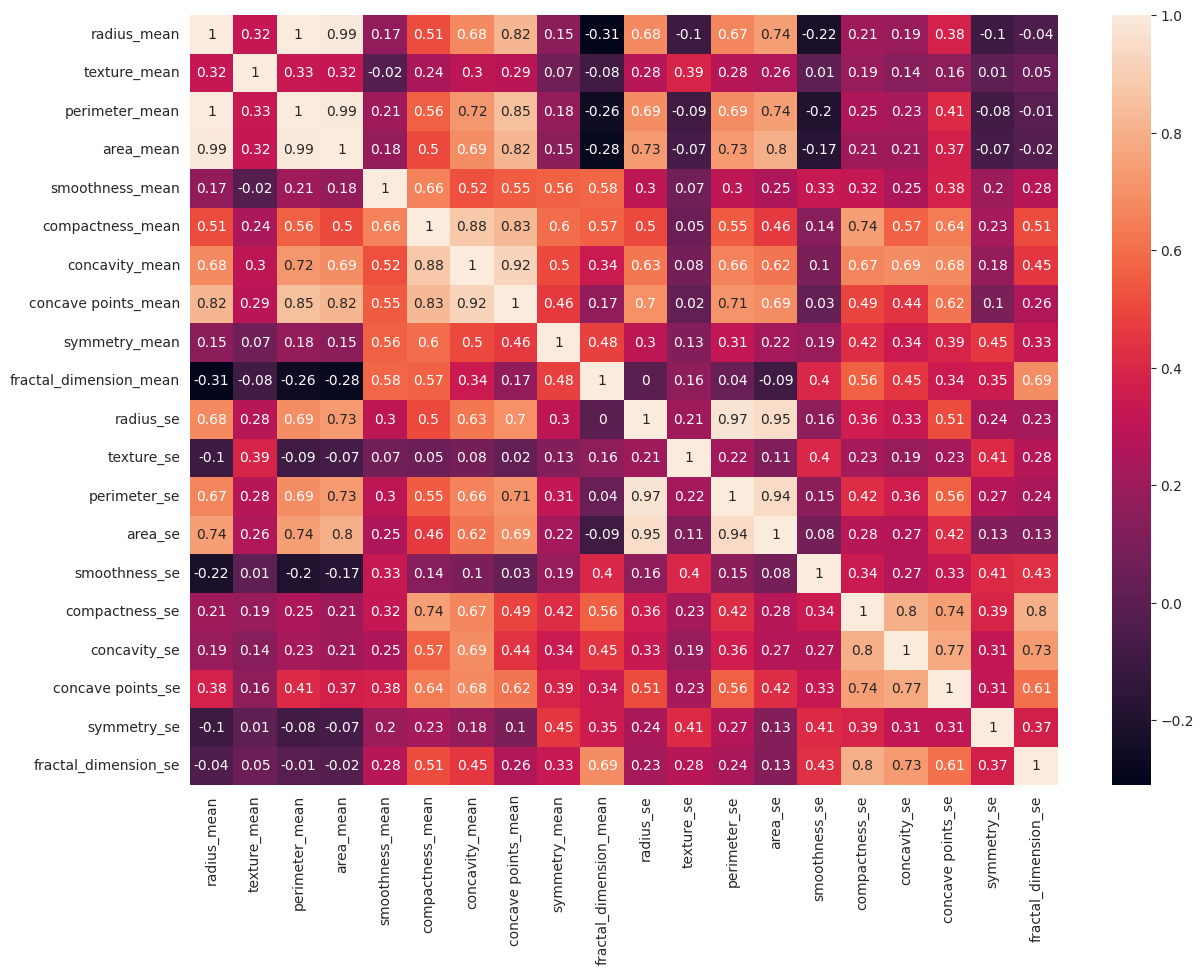

In [210]:
#Se despliega el mapa de calor para todas las variables numéricas
plt.figure(figsize = (14, 10))
sns.heatmap(round(data_df.corr (numeric_only = True),2), annot = True)

3d) Después de observar los valores, nos quedaremos con sólo una variable de cada trío: `radius_mean` y `compactness_mean`. Elimina las restantes, no sólo del conjunto `_mean`, sino también de `_se`.

In [211]:
#Se deja solo la variable radius y compactness de cada conjunto
data_df = data_df.drop(columns=['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean',
                                'perimeter_se', 'area_se', 'concavity_se', 'concave points_se'])
data_df

,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,
842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,0.11100,0.11590,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.01114,0.004239
926682,M,20.13,28.25,0.09780,0.10340,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.01898,0.002498
926954,M,16.60,28.08,0.08455,0.10230,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.01318,0.003892


Observa la distribución de las variables resultantes (deben ser 12):

4a) Utilizando histogramas. Guarda en una variable (`skew_cols`) las que tengan marcado sesgo positivo. Para dar seguridad a tu selección, elige aquellas cuyo resultado de aplicar la función `skew()` sea mayor a 1.

In [212]:
# Se hace una lista de variables numéricas y otra de categóricas
num_cols = data_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = data_df.select_dtypes(exclude=np.number).columns.tolist()

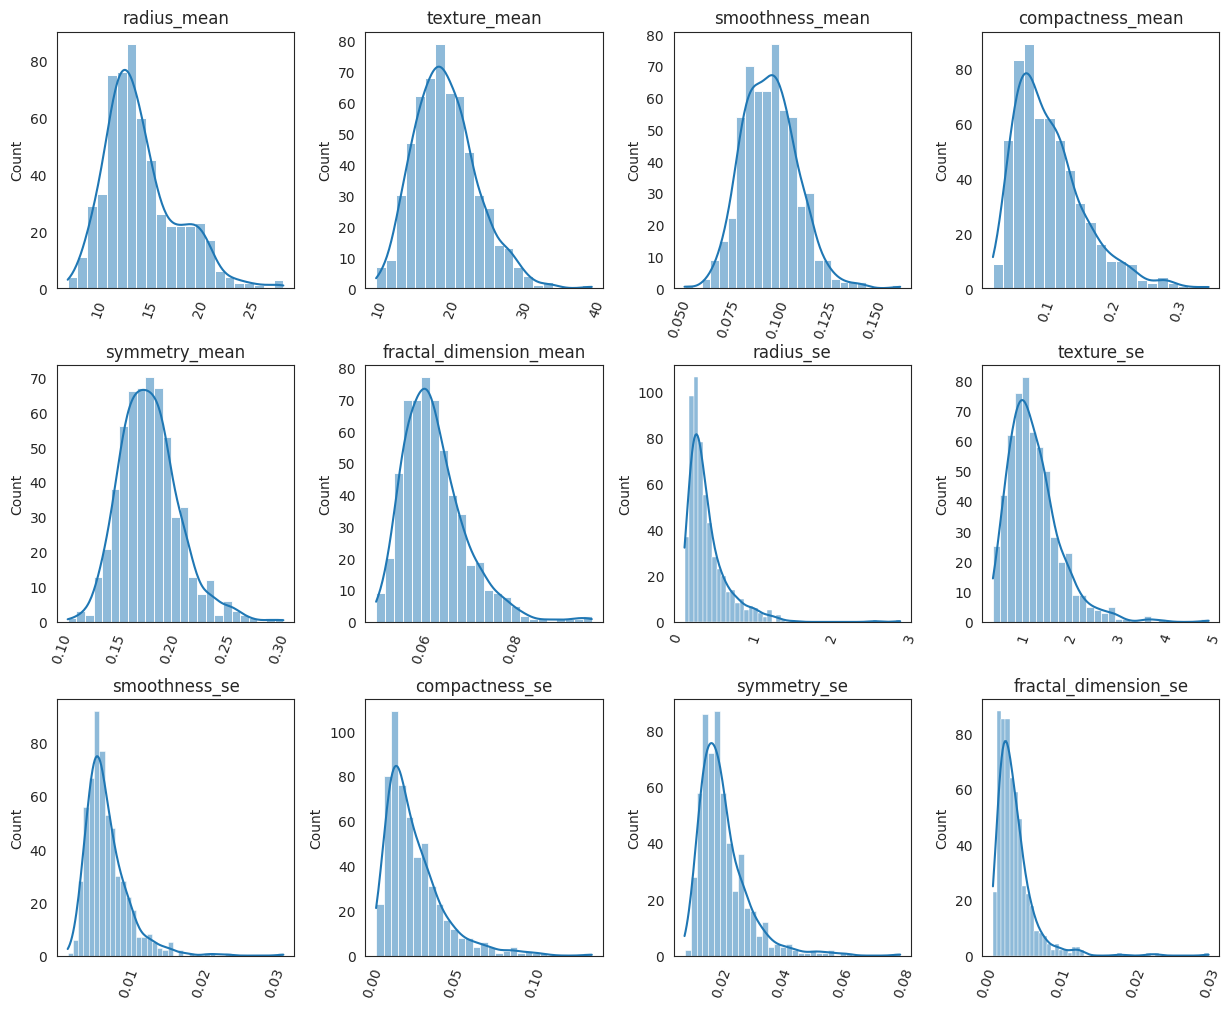

In [213]:
#Histogramas de variables
fig, axes = plt.subplots(3,4, figsize=(15,12))
plt.subplots_adjust(hspace = 0.3, wspace = 0.3)

axes = axes.ravel()
for col, ax in zip(data_df[num_cols], axes):
 sns.histplot(x=data_df[col], kde = True, ax=ax)
 ax.set(title=f'{col}', xlabel=None)
 ax.tick_params(axis='x',rotation=70)

In [214]:
#Cálculo de skew para cada variable
data_df.skew(numeric_only = True)

,0
radius_mean,0.942380
texture_mean,0.650450
smoothness_mean,0.456324
compactness_mean,1.190123
symmetry_mean,0.725609
fractal_dimension_mean,1.304489
radius_se,3.088612
texture_se,1.646444
smoothness_se,2.314450
compactness_se,1.902221


In [215]:
#Se toman solo las columnas que tienen un skew mayor a 1 y se guardan en una variable
skew_cols = data_df.skew(numeric_only = True)[abs(data_df.skew(numeric_only = True)) > 1].index
skew_cols

Index(['compactness_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se',
       'smoothness_se', 'compactness_se', 'symmetry_se',
       'fractal_dimension_se'],
      dtype='object')



---

***Las columnas con un skew mayor a 1 son: 'compactness_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se',
       'smoothness_se', 'compactness_se', 'symmetry_se',
       'fractal_dimension_se'***


---



4b) Dibujando box plots de todas las variables. Guarda en una variable (`scale_cols`) aquellas que no se encuentren en el intervalo [0,1]


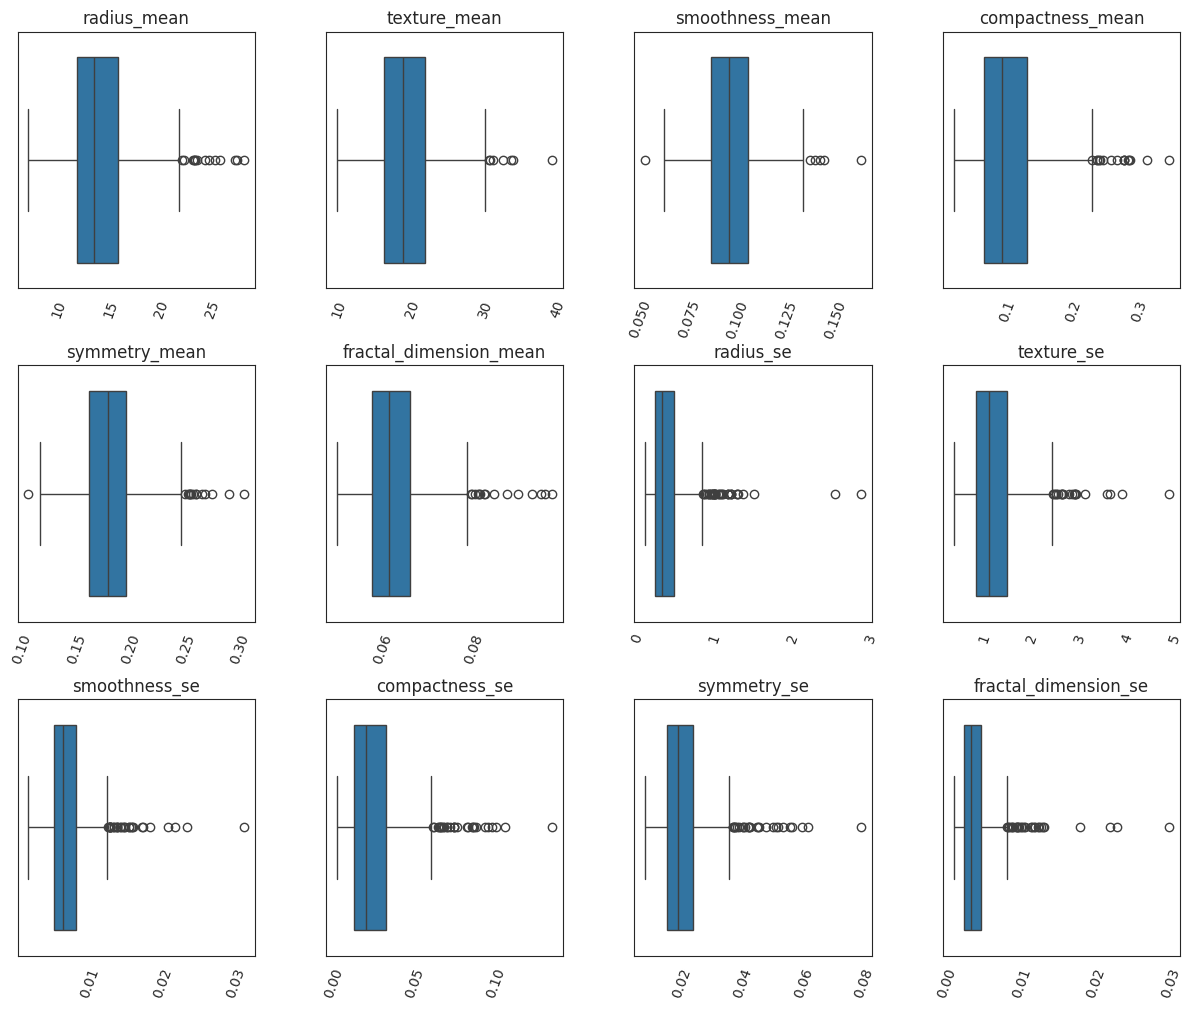

In [216]:
#Boxplot de variables
fig, axes = plt.subplots(3,4, figsize=(15,12))
plt.subplots_adjust(hspace = 0.3, wspace = 0.3)

axes = axes.ravel()
for col, ax in zip(data_df[num_cols], axes):
 sns.boxplot(x=data_df[col], ax=ax)
 ax.set(title=f'{col}', xlabel=None)
 ax.tick_params(axis='x',rotation=70)

In [217]:
scale_cols=[]
for column in data_df.select_dtypes(include=['float64']).columns:
  if data_df[column].min() < 0 or data_df[column].max() > 1:
    print('Columna con escala mayor a 1',column,'\n')
    scale_cols.append(column)

print(scale_cols)

Columna con escala mayor a 1 radius_mean 

Columna con escala mayor a 1 texture_mean 

Columna con escala mayor a 1 radius_se 

Columna con escala mayor a 1 texture_se 

['radius_mean', 'texture_mean', 'radius_se', 'texture_se']


---

***Las columnas con escala mayor a 1 son: 'radius_mean', 'texture_mean', 'radius_se', 'texture_se'***


---

Con todo el análisis anterior, estamos listos para generar un modelo *baseline* denominado `logr_model`. Para ello:

5a) Vuelve a leer el contenido del archivo, haz que el `id` sea el índice y separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`diagnosis`). Divide el conjunto en entrenamiento y prueba (80:20) considerando el parámetro `random_state` con el valor de 1.

In [218]:
#Se vuelve a leer el archivo
data_df = pd.read_csv('data.csv')
data_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [219]:
#El id se vuelve el indice
data_df.set_index('id', inplace=True)
data_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820


In [220]:
#Separación de variables
y = data_df.loc[:,'diagnosis']
x = data_df.iloc[:,1:]
total_components = x.shape[1]

In [221]:
# Se divide el conjunto en entrenamiento y prueba (80:20)
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, stratify = y, random_state=1)

5b) Prepara un transformador, denominado `preprocessing`, para borrar las columnas altamente correlacionadas (las 18 variables que se determinaron en los ejercicios previos) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.

In [222]:
#Se prepara un transformador para eliminar las columnas correlacionadas
preprocessing = ColumnTransformer(transformers=[('drop_columns', 'drop', ['radius_worst','texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
                                                                          'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst',
                                                                          'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 'area_se',
                                                                          'concavity_se', 'concave points_se'])], remainder='passthrough',
                                  verbose_feature_names_out=False)

In [223]:
#Visualización de los cambios que produce el pipeline "preprocessing" creado anteriormente
Xtrain_prepared = preprocessing.fit_transform(Xtrain)
Xtrain_prepared_df = pd.DataFrame(Xtrain_prepared, columns=preprocessing.get_feature_names_out(), index=Xtrain.index)
Xtrain_prepared_df

,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,
875878,12.91,16.33,0.07941,0.05366,0.1829,0.05667,0.1942,0.9086,0.005298,0.015870,0.01853,0.002152
925292,14.05,27.15,0.09929,0.11260,0.1537,0.06171,0.3645,1.4920,0.007256,0.026780,0.02080,0.005304
922297,13.87,20.70,0.09578,0.10180,0.1620,0.06688,0.2720,1.0470,0.006298,0.021720,0.01490,0.003599
914333,14.87,20.21,0.09587,0.08345,0.1487,0.05748,0.2323,1.6360,0.005415,0.013710,0.01959,0.001812
91813702,12.34,12.27,0.09003,0.06307,0.1689,0.05808,0.1166,0.4957,0.003681,0.009169,0.01129,0.001366
...,...,...,...,...,...,...,...,...,...,...,...,...
905189,16.14,14.86,0.09495,0.08501,0.1735,0.05875,0.2387,0.6372,0.003958,0.012460,0.01500,0.001621
8712289,23.27,22.04,0.08439,0.11450,0.1801,0.05553,0.6642,0.8561,0.004910,0.025440,0.01956,0.003740
91979701,14.27,22.55,0.10380,0.11540,0.1926,0.05982,0.2027,1.8510,0.006113,0.025830,0.01451,0.003756


5c) Entrena el modelo `logr_model` con el transformador `preprocessing` y  regresión logística.

Como la salida `y` está en términos de las etiquetas `'B'` y `'M'`, en lugar de 0 y 1, para evaluar el modelo en el conjunto de prueba deberás especificar la clase positiva. En el caso de la matriz de confusión, indica el orden de las etiquetas con `labels=['B','M']`, porque `'B'` es la clase negativa (ésta se especifica primero) y `'M'` la positiva. Para las métricas de *recall* y *precision*, utiliza el parámetro `pos_label='M'`. Como *accuracy* ocupa la suma de ambas clases y el total de las observaciones, no requiere ninguna especificación. Si quisieras omitir estos parámetros, tendrías que sustituir `'B'` por 0 y `'M'` por 1, previo a la construcción del modelo.

In [224]:
#Se entrena el modelo con el transformador y regresión logística
logr_model = make_pipeline(preprocessing, LogisticRegression())
logr_model.fit(Xtrain, ytrain)
y_predict = logr_model.predict(Xtest)
y_predict[:10]

array(['B', 'B', 'B', 'M', 'B', 'M', 'M', 'M', 'B', 'B'], dtype=object)

In [225]:
#Se obtiene la matriz de confusión

print('Matriz de Confusión:\n')
print('                   Valores de predicción')
print('                   ---------------------')
print('                   Negativos   Positivos')
print('Valores |Negativos ', confusion_matrix(ytest, y_predict, labels = ['B', 'M'])[:1,:1], '     ', confusion_matrix(ytest, y_predict, labels = ['B', 'M'])[:1,1:2])
print(' Reales |Positivos ', confusion_matrix(ytest, y_predict, labels = ['B', 'M'])[1:2,:1], '     ', confusion_matrix(ytest, y_predict, labels = ['B', 'M'])[1:2,1:2],'\n')
print('Precision = ', precision_score(ytest, y_predict, pos_label = 'M'))
print('Recall = ', recall_score(ytest, y_predict, pos_label = 'M'))
print('Accuracy = ', accuracy_score(ytest, y_predict))

Matriz de Confusión:

                   Valores de predicción
                   ---------------------
                   Negativos   Positivos
Valores |Negativos  [[70]]       [[2]]
 Reales |Positivos  [[7]]       [[35]] 

Precision =  0.9459459459459459
Recall =  0.8333333333333334
Accuracy =  0.9210526315789473


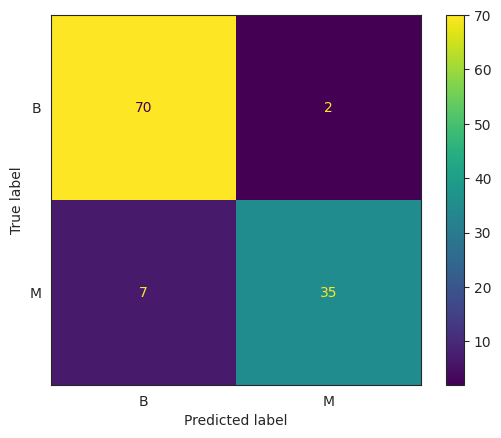

In [226]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

#Matriz de Confusion
cm=confusion_matrix(ytest, y_predict, labels=['B','M'])
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['B','M'])
disp.plot()

Para generar un modelo `logr_model2` con transformación y escalamiento:

6a) Modifica el transformador anterior para, además del borrado de las columnas correlacionadas, aplicar la raíz cuadrada a los predictores con sesgo (previamente almacenados en `skew_cols`) y escalamiento *MinMax* a los predictores con escala mayor a 1 (previamente almacenados en `scale_cols`) Como no todos los predictores serán eliminados o transformados, asegúrate de incluir el parámetro `remainder='passthrough'`

In [227]:
#Se prepara un transformador para eliminar las columnas correlacionadas y aplicar raíz cuadrada y MinMax
sqrt_transformer = FunctionTransformer(np.sqrt, validate=True)
num_pipeline = make_pipeline(MinMaxScaler())

preprocessing2 = ColumnTransformer(transformers=[('drop_columns', 'drop', ['radius_worst','texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
                                                                          'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst',
                                                                          'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 'area_se',
                                                                          'concavity_se', 'concave points_se']),
                                                 ('sqrt', sqrt_transformer, skew_cols),
                                                 ('num', num_pipeline, scale_cols)
                                                 ], remainder='passthrough',
                                  verbose_feature_names_out=False)

In [228]:
#Visualización de los cambios que produce el pipeline "preprocessing" creado anteriormente
Xtrain2_prepared = preprocessing2.fit_transform(Xtrain)
num_feature_names = list(preprocessing2.named_transformers_['num'].get_feature_names_out())

remainder_cols = [col for col in Xtrain.columns
                    if col not in preprocessing2.transformers_[0][2]  # drop_columns
                    and col not in skew_cols
                    and col not in scale_cols]

feature_names = skew_cols.tolist() + num_feature_names + remainder_cols

Xtrain2_prepared_df = pd.DataFrame(Xtrain2_prepared, columns=feature_names, index=Xtrain.index)
Xtrain2_prepared_df

,compactness_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se,radius_mean,texture_mean,radius_se,texture_se,smoothness_mean,symmetry_mean
id,,,,,,,,,,,,,,
875878,0.231646,0.238055,0.440681,0.953205,0.072787,0.125976,0.136125,0.046390,0.290083,0.274689,0.033956,0.121199,0.07941,0.1829
925292,0.335559,0.248415,0.603738,1.221475,0.085182,0.163646,0.144222,0.072829,0.345858,0.723651,0.103880,0.250133,0.09929,0.1537
922297,0.319061,0.258612,0.521536,1.023230,0.079360,0.147377,0.122066,0.059992,0.337052,0.456017,0.065900,0.151786,0.09578,0.1620
914333,0.288877,0.239750,0.481975,1.279062,0.073587,0.117090,0.139964,0.042568,0.385978,0.435685,0.049600,0.281957,0.09587,0.1487
91813702,0.251137,0.240998,0.341467,0.704060,0.060671,0.095755,0.106254,0.036959,0.262195,0.106224,0.002094,0.029946,0.09003,0.1689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905189,0.291565,0.242384,0.488569,0.798248,0.062913,0.111624,0.122474,0.040262,0.448114,0.213693,0.052227,0.061218,0.09495,0.1735
8712289,0.338378,0.235648,0.814985,0.925257,0.070071,0.159499,0.139857,0.061156,0.796957,0.511618,0.226935,0.109596,0.08439,0.1801
91979701,0.339706,0.244581,0.450222,1.360515,0.078186,0.160717,0.120457,0.061286,0.356622,0.532780,0.037446,0.329473,0.10380,0.1926


6b) Entrena el modelo `logr_model2` con regresión logística, aplicando previamente el transformador modificado. Evalúa el modelo en el conjunto de prueba con las mismas métricas.

In [229]:
#Se entrena el modelo con el transformador y regresión logística
logr_model2 = make_pipeline(preprocessing2, LogisticRegression())
logr_model2.fit(Xtrain, ytrain)
y_predict2 = logr_model2.predict(Xtest)
y_predict2[:10]

array(['M', 'B', 'B', 'M', 'B', 'M', 'M', 'M', 'B', 'B'], dtype=object)

In [230]:
#Se obtiene la matriz de confusión

print('Matriz de Confusión:\n')
print('                   Valores de predicción')
print('                   ---------------------')
print('                   Negativos   Positivos')
print('Valores |Negativos ', confusion_matrix(ytest, y_predict2, labels = ['B', 'M'])[:1,:1], '     ', confusion_matrix(ytest, y_predict2, labels = ['B', 'M'])[:1,1:2])
print(' Reales |Positivos ', confusion_matrix(ytest, y_predict2, labels = ['B', 'M'])[1:2,:1], '     ', confusion_matrix(ytest, y_predict2, labels = ['B', 'M'])[1:2,1:2],'\n')
print('Precision = ', precision_score(ytest, y_predict2, pos_label = 'M'))
print('Recall = ', recall_score(ytest, y_predict2, pos_label = 'M'))
print('Accuracy = ', accuracy_score(ytest, y_predict))

Matriz de Confusión:

                   Valores de predicción
                   ---------------------
                   Negativos   Positivos
Valores |Negativos  [[72]]       [[0]]
 Reales |Positivos  [[8]]       [[34]] 

Precision =  1.0
Recall =  0.8095238095238095
Accuracy =  0.9210526315789473


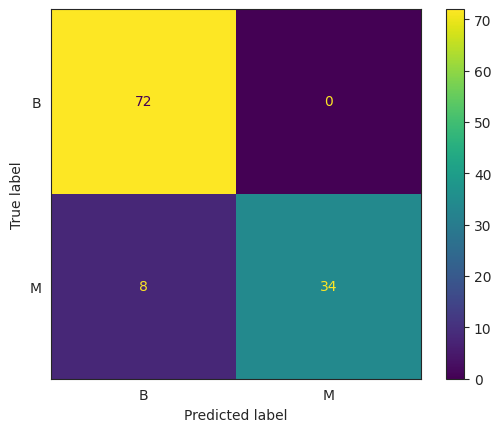

In [231]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

#Matriz de Confusion
cm=confusion_matrix(ytest, y_predict2, labels=['B','M'])
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['B','M'])
disp.plot()

# **Parte 3**. Modelo con aplicación de PCA

7. Analizaremos el efecto de aplicar PCA a todas las variables. Recuerda que previo a aplicarlo es recomendado escalar todas las variables. Utiliza la clase `StandardScaler` para transformar `X`.

In [232]:
#Escala los valores de x
from sklearn.preprocessing import StandardScaler
escalar = StandardScaler()
numerical_features = x.select_dtypes(include=np.number).columns
x_scaled = escalar.fit_transform(x[numerical_features])
x_scaled[0:5]

array([[ 1.09706398e+00, -2.07333501e+00,  1.26993369e+00,
         9.84374905e-01,  1.56846633e+00,  3.28351467e+00,
         2.65287398e+00,  2.53247522e+00,  2.21751501e+00,
         2.25574689e+00,  2.48973393e+00, -5.65265059e-01,
         2.83303087e+00,  2.48757756e+00, -2.14001647e-01,
         1.31686157e+00,  7.24026158e-01,  6.60819941e-01,
         1.14875667e+00,  9.07083081e-01,  1.88668963e+00,
        -1.35929347e+00,  2.30360062e+00,  2.00123749e+00,
         1.30768627e+00,  2.61666502e+00,  2.10952635e+00,
         2.29607613e+00,  2.75062224e+00,  1.93701461e+00],
       [ 1.82982061e+00, -3.53632408e-01,  1.68595471e+00,
         1.90870825e+00, -8.26962447e-01, -4.87071673e-01,
        -2.38458552e-02,  5.48144156e-01,  1.39236330e-03,
        -8.68652457e-01,  4.99254601e-01, -8.76243603e-01,
         2.63326966e-01,  7.42401948e-01, -6.05350847e-01,
        -6.92926270e-01, -4.40780058e-01,  2.60162067e-01,
        -8.05450380e-01, -9.94437403e-02,  1.80592744e+

8. Aplica PCA al conjunto escalado y determina el número de componentes que explican el 99% de la varianza.

In [233]:
#Se utiliza PCA para proyectar los datos
from sklearn.decomposition import PCA
pca = PCA()
x_projected = pca.fit_transform(x_scaled)
x_projected = pd.DataFrame(x_projected)
x_projected

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,9.192837,1.948583,-1.123166,-3.633731,1.195110,1.411424,2.159370,-0.398407,-0.157118,-0.877402,...,-0.096515,-0.068850,-0.084519,-0.175256,-0.151020,0.201503,-0.252585,0.033914,-0.045648,0.047169
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775,0.028656,0.013358,0.240988,-0.711905,1.106995,...,0.077327,0.094578,0.217718,0.011290,-0.170510,0.041129,0.181270,-0.032624,0.005687,0.001868
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086,0.541452,-0.668166,0.097374,0.024066,0.454275,...,-0.311067,0.060309,0.074291,0.102762,0.171158,-0.004735,0.049569,-0.047026,-0.003146,-0.000751
3,7.122953,10.275589,-3.232790,-0.152547,2.960878,3.053422,1.429911,1.059565,-1.405440,-1.116975,...,-0.434193,0.203266,0.124105,0.153430,0.077496,0.275225,0.183462,-0.042484,0.069295,0.019937
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747,-1.226495,-0.936213,0.636376,-0.263805,0.377704,...,0.116545,0.017650,-0.139454,-0.005332,0.003062,-0.039254,0.032168,0.034786,-0.005038,-0.021214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,6.439315,-3.576817,2.459487,-1.177314,0.074824,-2.375193,-0.596130,-0.035471,0.987929,0.256989,...,-0.006888,0.067000,-0.088590,0.107898,0.219520,0.122900,0.159198,-0.009853,-0.007119,0.001415
565,3.793382,-3.584048,2.088476,2.506028,0.510723,-0.246710,-0.716326,-1.113360,-0.105207,-0.108632,...,0.009802,-0.019563,0.055405,0.086135,0.001197,-0.065889,-0.068512,0.023575,0.027486,0.010419
566,1.256179,-1.902297,0.562731,2.089227,-1.809991,-0.534447,-0.192758,0.341887,0.393917,0.520877,...,0.036592,-0.063352,0.200312,-0.044819,0.002429,-0.007095,-0.023691,0.002578,-0.006706,-0.003770
567,10.374794,1.672010,-1.877029,2.356031,0.033742,0.567936,0.223082,-0.280239,-0.542035,-0.089296,...,-0.140648,0.042478,-0.168820,-0.195969,0.377830,0.198192,-0.027409,0.068086,0.084163,0.023783


In [234]:
#Despliega información principal
print("Valores propios: ", list(np.round(pca.explained_variance_, decimals=5)))
print("Porcentaje de varianza explicada por cada componente: ", list(np.round(pca.explained_variance_ratio_*100, decimals=5)))
print("Porcentaje de varianza acumulada: ", list(np.round(np.cumsum(pca.explained_variance_ratio_)*100, decimals=5)))
print("Numero de componentes principales: ", pca.n_components_)

Valores propios:  [13.30499, 5.70137, 2.82291, 1.98413, 1.65163, 1.20948, 0.67641, 0.47746, 0.41763, 0.35131, 0.29443, 0.26162, 0.24178, 0.15729, 0.0943, 0.08, 0.0595, 0.05271, 0.04956, 0.03121, 0.03003, 0.02749, 0.02438, 0.01809, 0.01551, 0.00819, 0.00691, 0.00159, 0.00075, 0.00013]
Porcentaje de varianza explicada por cada componente:  [44.27203, 18.97118, 9.39316, 6.60213, 5.49577, 4.02452, 2.25073, 1.58872, 1.38965, 1.16898, 0.97972, 0.87054, 0.80452, 0.52337, 0.31378, 0.26621, 0.198, 0.1754, 0.16493, 0.10386, 0.09991, 0.09146, 0.08114, 0.06018, 0.0516, 0.02726, 0.023, 0.0053, 0.0025, 0.00044]
Porcentaje de varianza acumulada:  [44.27203, 63.24321, 72.63637, 79.23851, 84.73427, 88.7588, 91.00953, 92.59825, 93.9879, 95.15688, 96.1366, 97.00714, 97.81166, 98.33503, 98.64881, 98.91502, 99.11302, 99.28841, 99.45334, 99.5572, 99.65711, 99.74858, 99.82971, 99.8899, 99.9415, 99.96876, 99.99176, 99.99706, 99.99956, 100.0]
Numero de componentes principales:  30


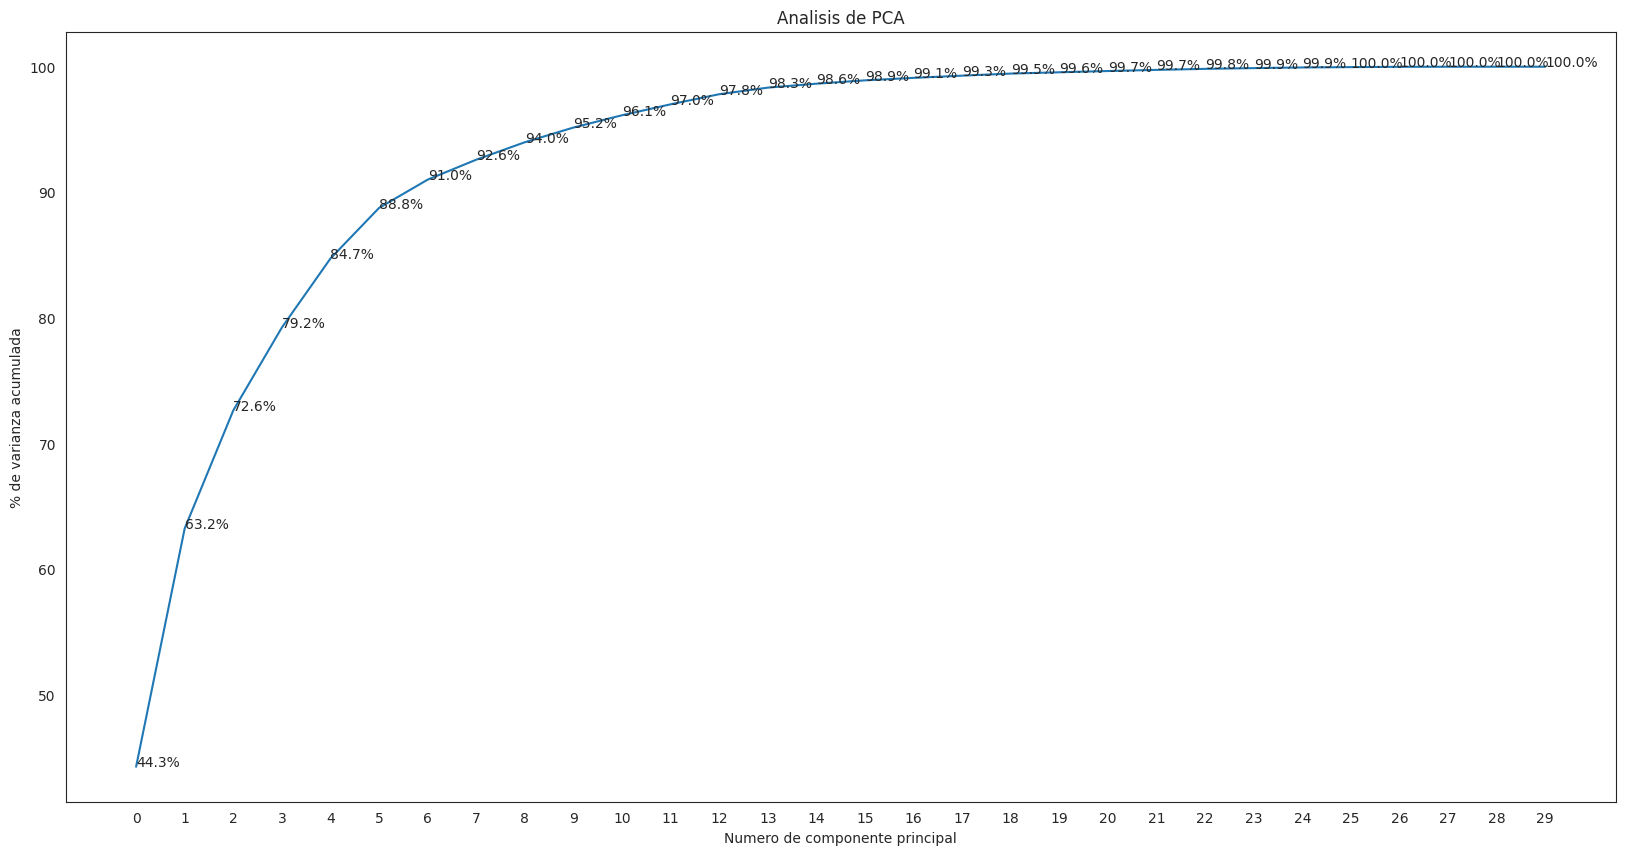

In [235]:
#Crea la curva de porcentaje de varianza
sns.set_style('white')

plt.figure(figsize=(20,10))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100)
plt.title('Analisis de PCA')
plt.xlabel('Numero de componente principal')
plt.ylabel('% de varianza acumulada')
plt.xticks(np.arange(0,pca.n_components_,1))

labels = np.cumsum(pca.explained_variance_ratio_)*100
for i in range(pca.n_components_):
  plt.text(i,labels[i],str(format(labels[i],'.1f'))+'%')



---
***Gracias a los valores obtenidos y al gráfico, se logra apreciar que el 99% de la varianza se explica con 17 componentes***


---




9. Con el número de componentes determinado, estamos listos para generar un modelo `logr_model3` con PCA. Construye un pipeline que incluya el escalamiento estándar, el PCA con el número de componentes determinado y regresión logística. Entrena el modelo utilizando el  conjunto de entrenamiento y evalúalo en el conjunto de prueba con las mismas métricas.

In [236]:
#Se entrena el modelo con el transformador y regresión logística
logr_model3 = make_pipeline(StandardScaler(), PCA(n_components = 17), LogisticRegression())
logr_model3.fit(Xtrain, ytrain)
y_predict3 = logr_model3.predict(Xtest)
y_predict3[:10]

array(['M', 'B', 'B', 'M', 'B', 'M', 'M', 'M', 'B', 'B'], dtype=object)

In [237]:
#Se crea la matriz de confusión

print('Matriz de Confusión:\n')
print('                   Valores de predicción')
print('                   ---------------------')
print('                   Negativos   Positivos')
print('Valores |Negativos ', confusion_matrix(ytest, y_predict3, labels = ['B', 'M'])[:1,:1], '     ', confusion_matrix(ytest, y_predict3, labels = ['B', 'M'])[:1,1:2])
print(' Reales |Positivos ', confusion_matrix(ytest, y_predict3, labels = ['B', 'M'])[1:2,:1], '     ', confusion_matrix(ytest, y_predict3, labels = ['B', 'M'])[1:2,1:2],'\n')
print('Precision = ', precision_score(ytest, y_predict3, pos_label = 'M'))
print('Recall = ', recall_score(ytest, y_predict3, pos_label = 'M'))
print('Accuracy = ', accuracy_score(ytest, y_predict3))

Matriz de Confusión:

                   Valores de predicción
                   ---------------------
                   Negativos   Positivos
Valores |Negativos  [[71]]       [[1]]
 Reales |Positivos  [[1]]       [[41]] 

Precision =  0.9761904761904762
Recall =  0.9761904761904762
Accuracy =  0.9824561403508771


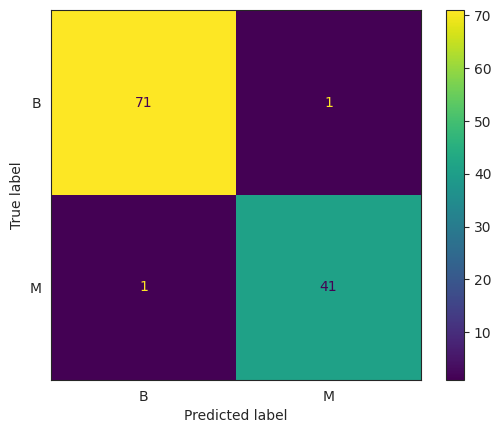

In [238]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

#Matriz de Confusion
cm=confusion_matrix(ytest, y_predict3, labels=['B','M'])
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['B','M'])
disp.plot()

10. En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante? ¿Cómo cambiarías (disminuir/aumentar) el *threshold*? ¿Por qué?



---
**En esta ocasión interesa conocer los valores positivos reales del diagnóstico ya que son en los que se deben tomar acciones (medicamento, operaciones, tratamiento, etc.) por lo que la sensibilidad seria una métrica crucial para saber cuantos valores positivos se predijeron correctamente con respecto al valor real de los mismos.**

***De acuerdo a lo modelos estudiados se observa que se tienen más falsos negativos que falsos positivos, estos es preocupante ya que el diagnóstico seria incorrecto y no se tomarian acciones, el reducir el threshold podría ayudar a que estos valores se conviertan en verdaderos positivos.***


---


